# Daniel Miller Notebook
# Intro to Jupyter and Exploratory Data Analysis (EDA)


- Author: [Daniel Miller](https://github.com/DMill31/)
- Repository: [datafun-04-notebooks](https://github.com/DMill31/datafun-04-notebooks/)
- Purpose: Demonstrate a repeatable EDA workflow for a new, unexplored dataset
- Date: 2026-06

## Dataset Information

- Dataset: Iris Dataset
- Description: Measurements of iris flowers from three species (Iris setosa, Iris versicolor, and Iris virginica)
- Source: Ronald A. Fisher, The Use of Multiple Measurements in Taxonomic Problems (1936)
- Original Collection: Edgar Anderson
- Citation: Fisher, R. A. (1936). The Use of Multiple Measurements in Taxonomic Problems. Annals of Eugenics, 7(2), 179-188.
- Access: Available via Seaborn's built-in datasets

## Section 0. Intro to EDA

### WHEN to do EDA

Perform Exploratory Data Analysis (EDA) when encountering a new data source, even if:

- You did not collect the data
- Someone else already analyzed it
- It comes from a trusted system

EDA helps to understand:

- What data is actually available
- What is missing, duplicated, or inconsistent
- What questions the data can and cannot answer

### GOALS of EDA

EDA is not the final report. EDA is about:

- Understanding structure and scale
- Detecting issues early
- Identifying next steps (cleaning, modeling, collection)

## Section 1. Project Setup and Imports

All imports and configuration appear once, at the top of the notebook.

WHY:
- Keeps notebooks readable and reproducible
- Mirrors professional scripts
- Makes it clear what must be installed

In [209]:
# This is a Python cell.


# === Section 1a. DECLARE IMPORTS (BRING IN FREE CODE) ===

import logging  # for type hinting only
from typing import Any, Final  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
from matplotlib.axes import Axes
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Type hint for Axes object (basic plot type returned by Seaborn)
# A seaborn plot is a set of axes. Set title, labels, etc. on the axes.
# A figure can contain multiple axes (plots)
# from matplotlib.figure import Figure

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("EDA-NB", level="DEBUG")
log_header(LOG, "EDA-NB")

# === Section 1c. Global Constants and Configuration ===

# CUSTOM: These are dataset-specific constants
# used in multiple places in the code.
# Inspect or explore the dataset to determine columns needed for analysis.

# CUSTOM: Data set name
DATASET_NAME: Final[str] = "iris"

# CUSTOM: Grouping column (chose one categorical/non-numeric variable)
GROUP_COL: Final[str] = "species"

# CUSTOM: Numeric columns to analyze (chose 4-5 numeric variables)
SELECTED_NUMERIC_COLS: Final[list[str]] = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
]

# === Section 1d. Pandas Configuration for Display ===

# Pandas display configuration (helps in notebooks)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

LOG.info("Imports complete.")

2026-06-03 17:55:25 | INFO | EDA-NB | === RUN START ===
2026-06-03 17:55:25 | INFO | EDA-NB | project=EDA-NB
2026-06-03 17:55:25 | INFO | EDA-NB | repo_dir=datafun-04-notebooks
2026-06-03 17:55:25 | INFO | EDA-NB | python=3.14.3
2026-06-03 17:55:25 | INFO | EDA-NB | os=Windows 11
2026-06-03 17:55:25 | INFO | EDA-NB | shell=powershell
2026-06-03 17:55:25 | INFO | EDA-NB | cwd=notebooks
2026-06-03 17:55:25 | INFO | EDA-NB | github_actions=False
2026-06-03 17:55:25 | INFO | EDA-NB | Imports complete.


## Section 2. Load the Data

This is a Markdown cell.

WHY: Before analysis, load the data to confirm:

- The dataset loads successfully
- The structure matches expectations
- Column names are available and readable

In [210]:
# Python cell

# Load a dataset into a DataFrame.

# Seaborn provides clean built-in datasets for practice.
# Other projects may load from CSV, JSON, or a database.

# Load the penguins dataset from Seaborn
# Into a pandas DataFrame (2D table)
LOG.info(f"Loading dataset: {DATASET_NAME}")
df: pd.DataFrame = sns.load_dataset(DATASET_NAME)
LOG.info(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

2026-06-03 17:55:25 | INFO | EDA-NB | Loading dataset: iris
2026-06-03 17:55:25 | INFO | EDA-NB | Loaded: 150 rows, 5 columns


## Section 3. Inspect Data Shape and Structure

WHY: Always start by understanding what columns exist,
what types they are, and how large the dataset is.

- How many rows and columns are there?
- What types of data are present?
- Are there obvious missing values?

This step determines challenges we might have downstream (later).

In [211]:
# Section 3 Python cell

# Preview the first few rows
# WHY: display() renders the DataFrame as a formatted table in the notebook.
#      A naked expression like df.head() only renders if it is the LAST line in a cell.
LOG.info("Previewing first few rows of the dataset")
display(df.head())

2026-06-03 17:55:25 | INFO | EDA-NB | Previewing first few rows of the dataset


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [212]:
# Section 3 Python cell

LOG.info("Column names")
print(list(df.columns))

2026-06-03 17:55:25 | INFO | EDA-NB | Column names


['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


In [213]:
# Section 3 Python cell

# DataFrame info (types and non-null counts)
# WHY: df.info() prints directly - no display() needed.
LOG.info("DataFrame info (types and non-null counts)")
df.info()

2026-06-03 17:55:25 | INFO | EDA-NB | DataFrame info (types and non-null counts)


<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [214]:
# Section 3 Python cell

# Get shape - number of rows and columns
# It has two parts so the return value is a tuple of (num_rows, num_columns)
shape: tuple[int, int] = df.shape

# To get each value, we can unpack the tuple into two variables
# This is a common Python idiom for working with tuples.
# Or we could just use shape[0] and shape[1] directly without unpacking.

num_rows, num_cols = shape

LOG.info(f"Dataset shape: {num_rows} rows, {num_cols} columns")

2026-06-03 17:55:25 | INFO | EDA-NB | Dataset shape: 150 rows, 5 columns


## Section 4. Create Data Dictionary and Check Data Quality

WHY: A data dictionary helps with understanding the structure and quality of the data.

WHY: Missing data is normal. We need to find out how much and where.

Missing data affects:

- Visualizations
- Summary statistics
- Machine learning models

LOOK FOR: 

- Columns with many missing values
- Patterns (entire rows missing multiple fields)

In [215]:
# Section 4 Python cell

LOG.info("Building starter data dictionary")

data_dictionary = pd.DataFrame(
    {
        "column": df.columns,
        "dtype": [str(t) for t in df.dtypes],
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().mean() * 100).round(2).values,
    }
)

LOG.debug(f"\n{data_dictionary}")

2026-06-03 17:55:25 | INFO | EDA-NB | Building starter data dictionary
2026-06-03 17:55:25 | DEBUG | EDA-NB | 
         column    dtype  missing_count  missing_pct
0  sepal_length  float64              0          0.0
1   sepal_width  float64              0          0.0
2  petal_length  float64              0          0.0
3   petal_width  float64              0          0.0
4       species      str              0          0.0


In [216]:
# Section 4 Python cell

LOG.info("Missing values per column:")
LOG.info(df.isnull().sum())

LOG.info("Checking missing values per column")
LOG.debug(f"\n{df.isna().sum().sort_values(ascending=False)}")

dup_count = int(df.duplicated().sum())
LOG.info(f"Duplicate rows detected: {dup_count}")

LOG.info("Call describe() for numeric columns")
LOG.debug(f"\n{df[SELECTED_NUMERIC_COLS].describe()}\n")

2026-06-03 17:55:25 | INFO | EDA-NB | Missing values per column:
2026-06-03 17:55:25 | INFO | EDA-NB | sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64
2026-06-03 17:55:25 | INFO | EDA-NB | Checking missing values per column
2026-06-03 17:55:25 | DEBUG | EDA-NB | 
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64
2026-06-03 17:55:25 | INFO | EDA-NB | Duplicate rows detected: 1
2026-06-03 17:55:25 | INFO | EDA-NB | Call describe() for numeric columns
2026-06-03 17:55:25 | DEBUG | EDA-NB | 
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4

## Section 5. Create Clean View for EDA

Create a cleaned view for EDA.

Strategy:
  - Keep the original DataFrame unchanged
  - Drop rows missing key numeric fields and grouping field

WHY: EDA often focuses on a "clean" subset of the data.

This allows exploring patterns without being distracted by missing values.

In [217]:
# Section 5 Python cell

# Build the list of columns we require to be non-missing
# This includes all the selected numeric columns plus the grouping column.
# SELECTED_NUMERIC_COLS is a list of strings,
# GROUP_COL is a single string
# Wrap GROUP_COL in a list - two lists can be combined with +
cols_required: list[str] = SELECTED_NUMERIC_COLS + [GROUP_COL]
LOG.debug(f"Columns required to be non-missing: {cols_required}")

# Drop a row if it is missing a value in ANY of the required columns
# dropna(subset=...) only looks at the specified columns, not the whole row
# .copy() creates a new DataFrame so we don't accidentally modify the original
df_clean: pd.DataFrame = df.dropna(subset=cols_required).copy()

# Compare sizes
count_original: int = df.shape[0]
count_clean: int = df_clean.shape[0]
count_dropped: int = count_original - count_clean

print(f"Original rows: {count_original}")
print(f"Clean rows:    {count_clean}")
print(f"Rows dropped:  {count_dropped}")

LOG.info(f"Original rows: {count_original}")
LOG.info(f"Clean rows:    {count_clean}")
LOG.info(f"Rows dropped:  {count_dropped}")

2026-06-03 17:55:25 | DEBUG | EDA-NB | Columns required to be non-missing: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
2026-06-03 17:55:25 | INFO | EDA-NB | Original rows: 150
2026-06-03 17:55:25 | INFO | EDA-NB | Clean rows:    150
2026-06-03 17:55:25 | INFO | EDA-NB | Rows dropped:  0


Original rows: 150
Clean rows:    150
Rows dropped:  0


## Section 6. Descriptive Statistics for Numeric Columns

WHY: Summary statistics offer a quick overview of numeric data:

- Central tendency (mean)
- Spread (std, min, max)
- Distribution shape (quartiles)

Grouping by a categorical variable (i.e., non-numeric column)
enables comparing statistics across categories

In [218]:
# Section 6 Python cell

LOG.info("--------------- Manual statistics ---------------")

# Example: Calculate statistics for a specific column with numpy
mean_petal_length = np.mean(df_clean["petal_length"])
std_petal_length = np.std(df_clean["petal_length"])
min_petal_length = np.min(df_clean["petal_length"])
max_petal_length = np.max(df_clean["petal_length"])
# np.ptp() (peak to peak) is deprecated - use max - min instead
range_petal_length = np.max(df_clean["petal_length"]) - np.min(df_clean["petal_length"])

# Log the example results with formatting
LOG.info("Petal Length Statistics (using numpy):")
LOG.info(f"  Mean: {mean_petal_length:.2f} ")
LOG.info(f"  Std Dev: {std_petal_length:.2f} ")
LOG.info(f"  Min: {min_petal_length:.2f} ")
LOG.info(f"  Max: {max_petal_length:.2f} ")
LOG.info(f"  Range: {range_petal_length:.2f} ")

2026-06-03 17:55:25 | INFO | EDA-NB | --------------- Manual statistics ---------------
2026-06-03 17:55:25 | INFO | EDA-NB | Petal Length Statistics (using numpy):
2026-06-03 17:55:25 | INFO | EDA-NB |   Mean: 3.76 
2026-06-03 17:55:25 | INFO | EDA-NB |   Std Dev: 1.76 
2026-06-03 17:55:25 | INFO | EDA-NB |   Min: 1.00 
2026-06-03 17:55:25 | INFO | EDA-NB |   Max: 6.90 
2026-06-03 17:55:25 | INFO | EDA-NB |   Range: 5.90 


In [219]:
# Section 6 Python cell

# LOG.info("--------------- Using pandas describe() method ---------------")

LOG.info("Computing overall descriptive statistics")

# Use describe() to get count, mean, std, min, 25%, 50%, 75%, max for numeric columns
# OPTION: Use .T to transpose the result so that columns become rows for easier reading in logs
stats_overall = df_clean[SELECTED_NUMERIC_COLS].describe().T
LOG.debug(f"\n{stats_overall}")

LOG.info("--------------- Using pandas groupby() and agg() ---------------")

LOG.info("Computing descriptive statistics by group")

# Step 1: Select only the numeric columns we want to summarize
df_numeric_subset: pd.DataFrame = df_clean[SELECTED_NUMERIC_COLS]

# Step 2: Split the numeric subset into groups based on the grouping column
# groupby() returns a GroupBy object - not a DataFrame yet, just a plan to group
grouped = df_numeric_subset.groupby(df_clean[GROUP_COL])

# Step 3: For each group, compute multiple summary statistics at once
# agg() applies each function in the list to each numeric column
# The result has a multi-level column index: (numeric_column, statistic)
df_stats_by_group: pd.DataFrame = grouped.agg(["count", "mean", "std", "min", "max"])

LOG.debug(f"\n{df_stats_by_group}")

2026-06-03 17:55:25 | INFO | EDA-NB | Computing overall descriptive statistics
2026-06-03 17:55:25 | DEBUG | EDA-NB | 
              count      mean       std  min  25%   50%  75%  max
sepal_length  150.0  5.843333  0.828066  4.3  5.1  5.80  6.4  7.9
sepal_width   150.0  3.057333  0.435866  2.0  2.8  3.00  3.3  4.4
petal_length  150.0  3.758000  1.765298  1.0  1.6  4.35  5.1  6.9
petal_width   150.0  1.199333  0.762238  0.1  0.3  1.30  1.8  2.5
2026-06-03 17:55:25 | INFO | EDA-NB | --------------- Using pandas groupby() and agg() ---------------
2026-06-03 17:55:25 | INFO | EDA-NB | Computing descriptive statistics by group
2026-06-03 17:55:25 | DEBUG | EDA-NB | 
           sepal_length                            sepal_width                            petal_length         \
                  count   mean       std  min  max       count   mean       std  min  max        count   mean   
species                                                                                               

In [220]:
# Section 6 Python cell

LOG.info("--------------- Improving the output ---------------")

# Yuck: That's the multi-level column index in action.
# pandas lays out the result as (numeric_column, statistic) pairs
# side by side, wrapping when the terminal width runs out.
# With 4 numeric columns x 5 statistics = 20 columns total,
# it can only fit 2 numeric columns per line at 120 characters wide.
# Let's stack it so each numeric column's stats are grouped together
# vertically instead of horizontally.

stats_by_group_stacked: pd.DataFrame | pd.Series[Any] = df_stats_by_group.stack(level=0)
LOG.debug(f"\n{stats_by_group_stacked}")

2026-06-03 17:55:25 | INFO | EDA-NB | --------------- Improving the output ---------------
2026-06-03 17:55:25 | DEBUG | EDA-NB | 
                         count   mean       std  min  max
species                                                  
setosa     sepal_length     50  5.006  0.352490  4.3  5.8
           sepal_width      50  3.428  0.379064  2.3  4.4
           petal_length     50  1.462  0.173664  1.0  1.9
           petal_width      50  0.246  0.105386  0.1  0.6
versicolor sepal_length     50  5.936  0.516171  4.9  7.0
           sepal_width      50  2.770  0.313798  2.0  3.4
           petal_length     50  4.260  0.469911  3.0  5.1
           petal_width      50  1.326  0.197753  1.0  1.8
virginica  sepal_length     50  6.588  0.635880  4.9  7.9
           sepal_width      50  2.974  0.322497  2.2  3.8
           petal_length     50  5.552  0.551895  4.5  6.9
           petal_width      50  2.026  0.274650  1.4  2.5


## Section 7. Simple Correlations (Numeric Only)

Compute a simple numeric correlations to understand
relationships between numeric variables.

A correlation matrix is symmetric.
There are as many columns as numeric variables.
There are as many rows as numeric variables.
The diagonal values are always exactly 1.0.
since each variable perfectly correlates with itself.

WHY: Correlation tells us how numeric variables relate to each other.

- Values near 1 or -1 indicate strong relationships
- Values near 0 indicate weak or no linear relationship


In [221]:
# Section 7 Python cell

LOG.info("Computing correlation matrix for numeric columns")

# Select only numeric columns
df_clean_numeric_cols: pd.DataFrame = df_clean.select_dtypes(include="number")

# calculate the correlation matrix using the df corr() method
correlation_matrix = df_clean_numeric_cols.corr()

LOG.info("\nCorrelation matrix:")
LOG.debug(f"\n{correlation_matrix}")

2026-06-03 17:55:25 | INFO | EDA-NB | Computing correlation matrix for numeric columns
2026-06-03 17:55:25 | INFO | EDA-NB | 
Correlation matrix:
2026-06-03 17:55:25 | DEBUG | EDA-NB | 
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


2026-06-03 17:55:25 | INFO | EDA-NB | ---------Visualize Correlation Matrix as a Heatmap---------------


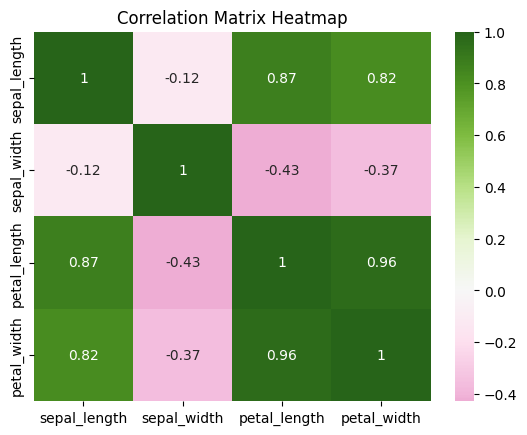

In [222]:
# Section 7 Python cell

LOG.info("---------Visualize Correlation Matrix as a Heatmap---------------")

# Set annotations to True to show correlation values
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="PiYG",  # try coolwarm, viridis, plasma, or other colormaps
    center=0,
)
plt.title("Correlation Matrix Heatmap")
plt.show()

CUSTOM: Update these notes and use Markdown cells to narrate and tell the story as you explore. For example:

Interpretation:

 - Values close to 1 (dark green) = strong positive correlation (both increase together)
 - Values close to -1 (dark pink) = strong negative correlation (one increases, other decreases)
 - Values close to 0 (white) = little or no linear relationship
 - The diagonal is always 1 (each variable correlates perfectly with itself)

From this heatmap, we can see that **petal_length** and **petal_width** show strong positive correlation (~0.96).

Similarly, **sepal_length** has a strong correlation with **petal_length** and **petal_width** (~0.87 & ~0.82).

## Section 8. Make Plots

Create simple, notebook-friendly plots.

WHY: Visualizations reveal patterns not obvious in tables.
CUSTOM: Charts will vary depending on the dataset
        and questions of interest.

Common charts include:
1. A scatter plot to see relationships between two variables
2. A box plot to compare distributions across groups

A scatter plot shows the relationship between two numeric variables.
In this example:
- Each dot is one data record shown as x vs y.
- Color (hue) provides a third dimension.

A box plot shows the distribution of one numeric variable across groups.
- The box shows the middle 50% of values.
- The line inside the box is the median.
- The whiskers show the range. Dots beyond the whiskers are outliers.

A third chart will be included as well: A **histogram**

A histogram shows the distribution of one numeric variable without groups.
- Bars show the frequency of each range of values
- Distributions can be determined by shape of chart

2026-06-03 17:55:25 | INFO | EDA-NB | ---- Creating Scatter Plot to see Relationships ------
2026-06-03 17:55:25 | INFO | EDA-NB | ----   Use clean dataframe ---------------------------
2026-06-03 17:55:25 | INFO | EDA-NB | ----   Set x to petal length -------------------------
2026-06-03 17:55:25 | INFO | EDA-NB | ----   Set y to petal width --------------------------
2026-06-03 17:55:25 | INFO | EDA-NB | ----   Set the hue (color mapping) to the group column --


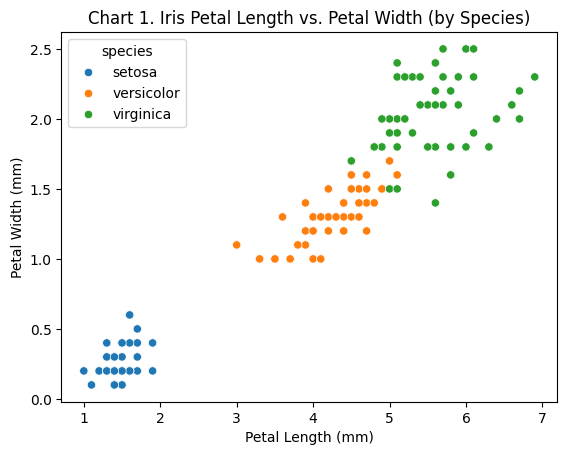

In [223]:
# Section 8 Python cell - use "Run All" so prior cells are executed first.

LOG.info("---- Creating Scatter Plot to see Relationships ------")
LOG.info("----   Use clean dataframe ---------------------------")
LOG.info("----   Set x to petal length -------------------------")
LOG.info("----   Set y to petal width --------------------------")
LOG.info("----   Set the hue (color mapping) to the group column --")

# Scatter plot to see relationship
scatter_plt: Axes = sns.scatterplot(
    data=df_clean,
    x="petal_length",
    y="petal_width",
    hue=GROUP_COL,
)

# Set axis labels using the Matplotlib Axes methods set_xlabel() and set_ylabel()
scatter_plt.set_xlabel("Petal Length (mm)")
scatter_plt.set_ylabel("Petal Width (mm)")

# Set the title using the Matplotlib Axes set_title() method
scatter_plt.set_title("Chart 1. Iris Petal Length vs. Petal Width (by Species)")

# IN NOTEBOOK: SHOW AS YOU GO
#      plt.show() displays the current chart and closes it
#      Call this before starting a new chart
#      or next chart will be drawn on top of this one
# IN SCRIPT: WAIT TO SHOW TILL THE END
#      Do not call plt.show() here - let figures accumulate
#      so all charts display together with sequential Figure numbers.
#      plt.show() is called once at the end of make_plots()
plt.show()

2026-06-03 17:55:25 | INFO | EDA-NB | ------- Creating another chart -------
2026-06-03 17:55:25 | INFO | EDA-NB | ------ Creating Box Plot to see Distribution: ---------
2026-06-03 17:55:25 | INFO | EDA-NB | ------   Use clean dataframe --------------------------
2026-06-03 17:55:25 | INFO | EDA-NB | ------   Set x to the group column --------------------
2026-06-03 17:55:25 | INFO | EDA-NB | ------   Set y to petal length ------------------------


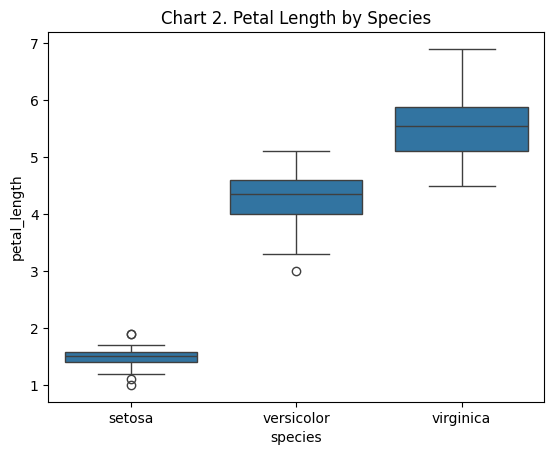

In [224]:
LOG.info("------- Creating another chart -------")
# plt.figure() opens a fresh blank canvas for the next chart
# WHY: Without this, Chart 2 draws on top of Chart 1
plt.figure()

LOG.info("------ Creating Box Plot to see Distribution: ---------")
LOG.info("------   Use clean dataframe --------------------------")
LOG.info("------   Set x to the group column --------------------")
LOG.info("------   Set y to petal length ------------------------")

# Box plot to compare distribution across species
box_plt: Axes = sns.boxplot(
    data=df_clean,
    x=GROUP_COL,
    y="petal_length",
)
box_plt.set_title("Chart 2. Petal Length by Species")

plt.show()

2026-06-03 17:55:25 | INFO | EDA-NB | ------- Creating final chart --------
2026-06-03 17:55:25 | INFO | EDA-NB | ------ Creating Histogram to see Distribution: --------
2026-06-03 17:55:25 | INFO | EDA-NB | ------   Use clean dataframe --------------------------
2026-06-03 17:55:25 | INFO | EDA-NB | ------   Set x to petal width -------------------------


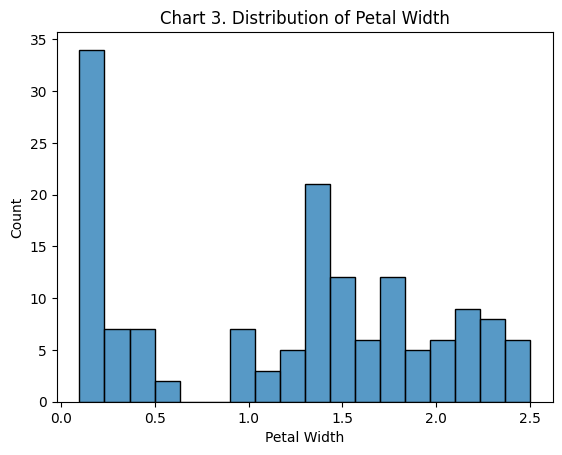

In [225]:
LOG.info("------- Creating final chart --------")

plt.figure()

LOG.info("------ Creating Histogram to see Distribution: --------")
LOG.info("------   Use clean dataframe --------------------------")
LOG.info("------   Set x to petal width -------------------------")

# Histogram to see distribution of petal width
hist_plt: Axes = sns.histplot(
    data=df_clean,
    x="petal_width",
    bins=18,
)
hist_plt.set_title("Chart 3. Distribution of Petal Width")
hist_plt.set_xlabel("Petal Width")
hist_plt.set_ylabel("Count")

plt.show()

## Section 9. Summary and Next Steps

At the end, of your notebook, provide:

-  brief summary of your findings 
-  suggested next steps

WHY: EDA is not a final report.
The summary of your data exploration captures you found 
and what you would like to investigate next.

This summary is in code because it is instructional - your summary
will typically be in Markdown as it is good for narrative. 


In [226]:
# Section 9 Python cell

LOG.info("========================")
LOG.info("SUMMARY")
LOG.info("========================")
LOG.info(f"Dataset: {DATASET_NAME}")

LOG.info(f"Original rows: {df.shape[0]}")
LOG.info(f"Clean rows:    {df_clean.shape[0]}")

# Get the unique values in the grouping column (e.g. species names)
unique_groups_array: np.ndarray = df_clean[GROUP_COL].unique()

# Sort them alphabetically so the output is consistent and readable
sorted_groups: list[str] = sorted(unique_groups_array)

LOG.info(f"Groups found in {GROUP_COL}: {sorted_groups}")

LOG.info("Strongest correlation: ")
LOG.info("  petal_length and petal_width (~0.96)")

LOG.info("Suggested next step: ")
LOG.info("  Model petal_width ~ petal_length with linear regression")

LOG.info("EDA workflow complete")
LOG.info("IMPORTANT: This script creates chart windows.")
LOG.info("Close any chart windows and terminate this process with CTRL+c as needed.")
LOG.info("========================")
LOG.info("Executed successfully!")
LOG.info("========================")

2026-06-03 17:55:25 | INFO | EDA-NB | ========================
2026-06-03 17:55:25 | INFO | EDA-NB | SUMMARY
2026-06-03 17:55:25 | INFO | EDA-NB | ========================
2026-06-03 17:55:25 | INFO | EDA-NB | Dataset: iris
2026-06-03 17:55:25 | INFO | EDA-NB | Original rows: 150
2026-06-03 17:55:25 | INFO | EDA-NB | Clean rows:    150
2026-06-03 17:55:25 | INFO | EDA-NB | Groups found in species: ['setosa', 'versicolor', 'virginica']
2026-06-03 17:55:25 | INFO | EDA-NB | Strongest correlation: 
2026-06-03 17:55:25 | INFO | EDA-NB |   petal_length and petal_width (~0.96)
2026-06-03 17:55:25 | INFO | EDA-NB | Suggested next step: 
2026-06-03 17:55:25 | INFO | EDA-NB |   Model petal_width ~ petal_length with linear regression
2026-06-03 17:55:25 | INFO | EDA-NB | EDA workflow complete
2026-06-03 17:55:25 | INFO | EDA-NB | IMPORTANT: This script creates chart windows.
2026-06-03 17:55:25 | INFO | EDA-NB | Close any chart windows and terminate this process with CTRL+c as needed.
2026-06-03